# Tutorial 08 — Working with DNA and RNA

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/master/docs/tutorial/08_nucleic_acids.ipynb)

TMol represents proteins, DNA, and RNA in the same tensor-backed `PoseStack`. This tutorial loads DNA and RNA structures, inspects nucleic-acid score terms and chi sampling, and runs small local packing examples.

## Learning objectives

- Load DNA, RNA, and a protein–DNA complex from mmCIF.
- Inspect nucleic-acid score terms and glycosidic chi sampling.
- Run a chemically matched base-pair swap under a fixed protein shell.
- Repack an RNA aptamer around a fixed small molecule.

## Before you begin

- **Prerequisites:** The core Tutorials 01–06; [07 — Ligands](07_ligand_and_params.ipynb) is recommended for the RNA–ligand section.
- **Curriculum:** This is the final specialized path after 06 and completes the numbered Tutorials sequence.
- **Related:** [Nucleic-acid workflow](../workflows/nucleic_acids.md) · [Scoring workflow](../user_guide/scoring.md)

TMol provides lower-level DNA/RNA primitives rather than full RosettaDNA or Rosetta RNA protocols. Short seeded runs are smoke tests; assess sampling and convergence separately.

## Setup

The three structures are checked into the repository so the executed documentation never depends on a live structure download. CIF is the primary input because it preserves richer chemical and author metadata than PDB; the ligand-bearing aptamer additionally uses CIF chemical-component bonds during ligand preparation.

In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "master/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab(
        [
            "tmol/tests/data/cif/1BNA.cif",
            "tmol/tests/data/cif/1HDD.cif",
            "tmol/tests/data/cif/1EHT.cif",
        ]
    )

In [2]:
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from biotite.structure.io import load_structure

import tmol
from tmol.database import ParameterDatabase
from tmol.io import pose_stack_from_biotite
from tmol.ops import (
    build_sidechain_coord_mask,
    compute_block_adjacency,
    compute_block_centroids_and_furthest_dist,
    res_mask_to_coord_mask,
)
from tmol.optimization import run_cart_min
from tmol.pack import PackerPalette, PackerTask, SetPackerTask, pack_rotamers
from tmol.pack.rotamer import (
    FixedAAChiSampler,
    IncludeCurrentSampler,
    NaChiRotamerSampler,
)
from tmol.pack.rotamer.dunbrack import create_dunbrack_sampler_from_database
from tmol.pose import PoseStackBuilder
from tmol.score import ScoreType, beta2016_score_function

SEED = 20260808
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = (
    torch.device("cuda", torch.cuda.current_device())
    if torch.cuda.is_available()
    else torch.device("cpu")
)
param_db = ParameterDatabase.get_default()
score_function = beta2016_score_function(device, param_db=param_db)
repo_root = Path.cwd()
if not (repo_root / "tmol/tests/data/cif/1BNA.cif").exists():
    repo_root = Path(tmol.__file__).resolve().parents[1]


def show_table(frame):
    try:
        from itables import show
    except ImportError:
        return display(frame)
    return show(frame)


def build_pose(atom_array, *, prepare_ligands=False, return_context=False):
    diagnostics = StringIO()
    try:
        with redirect_stdout(diagnostics), redirect_stderr(diagnostics):
            return pose_stack_from_biotite(
                atom_array,
                device,
                param_db=param_db,
                no_optH=True,
                prepare_ligands=prepare_ligands,
                return_context=return_context,
            )
    except Exception:
        print(diagnostics.getvalue())
        raise


def block_mask_for_chains(pose, chains):
    labels = np.asarray(pose.pdb_info.chain_labels)
    return torch.as_tensor(np.isin(labels, list(chains)), device=pose.device)


def block_mask_for_name3(pose, names):
    mask = torch.zeros_like(pose.block_type_ind, dtype=torch.bool)
    for pose_index in range(pose.n_poses):
        for block_index in range(pose.max_n_blocks):
            if int(pose.block_type_ind64[pose_index, block_index]) < 0:
                continue
            mask[pose_index, block_index] = pose.block_type(
                pose_index, block_index
            ).name3 in names
    return mask


NA_NAMES = {"DA", "DC", "DG", "DT", "A", "C", "G", "U"}
PROTON_CHI_HYDROGENS = {"HO2'", "HO3'", "HO5'"}
ELEMENT_BY_ATOM_TYPE = {
    atom_type.name: atom_type.element for atom_type in param_db.chemical.atom_types
}


def build_na_base_and_proton_chi_coord_mask(pose, block_mask):
    """Select NA bases and hydroxyl proton-chi atoms, fixing sugar/phosphate."""
    mask = torch.zeros_like(pose.real_atoms)
    for pose_index, block_index in torch.nonzero(block_mask, as_tuple=False).tolist():
        block_type = pose.block_type(pose_index, block_index)
        if block_type.name3 not in NA_NAMES:
            raise ValueError(f"Expected a nucleotide, got {block_type.name3}")
        offset = int(pose.block_coord_offset64[pose_index, block_index])
        for atom_index, atom in enumerate(block_type.atoms):
            name = atom.name
            is_sugar = "'" in name
            is_phosphate = (
                name == "P"
                or name.startswith("OP")
                or (name.startswith("O") and name.endswith("P"))
            )
            if (not is_sugar and not is_phosphate) or name in PROTON_CHI_HYDROGENS:
                mask[pose_index, offset + atom_index] = True
    return mask


def heavy_atom_coord_mask(pose, block_mask):
    mask = torch.zeros_like(pose.real_atoms)
    for pose_index, block_index in torch.nonzero(block_mask, as_tuple=False).tolist():
        block_type = pose.block_type(pose_index, block_index)
        offset = int(pose.block_coord_offset64[pose_index, block_index])
        for atom_index, atom in enumerate(block_type.atoms):
            if ELEMENT_BY_ATOM_TYPE.get(atom.atom_type) != "H":
                mask[pose_index, offset + atom_index] = True
    return mask


def atom_coord_for_block(pose, block_index, atom_name, pose_index=0):
    block_type = pose.block_type(pose_index, block_index)
    matching = [
        atom_index
        for atom_index, atom in enumerate(block_type.atoms)
        if atom.name == atom_name
    ]
    if len(matching) != 1:
        raise ValueError(
            f"Expected one {atom_name} in block {block_index} "
            f"({block_type.name3}); found {len(matching)}"
        )
    offset = int(pose.block_coord_offset64[pose_index, block_index])
    return pose.coords[pose_index, offset + matching[0]]


def named_atom_distance(pose, first_block, first_atom, second_block, second_atom):
    distance = torch.linalg.vector_norm(
        atom_coord_for_block(pose, first_block, first_atom)
        - atom_coord_for_block(pose, second_block, second_atom)
    )
    return float(distance.detach().cpu())


def interface_geometry_diagnostics(pose, first_blocks, second_blocks, cutoff=2.0):
    first = pose.coords[heavy_atom_coord_mask(pose, first_blocks)]
    second = pose.coords[heavy_atom_coord_mask(pose, second_blocks)]
    distances = torch.cdist(first, second)
    return {
        "minimum_intergroup_heavy_atom_distance_A": float(distances.min().detach().cpu()),
        f"intergroup_heavy_atom_pairs_below_{cutoff:g}A": int(
            (distances < cutoff).sum().detach().cpu()
        ),
    }


def covalent_bond_pairs(pose):
    """Return unique intra- and inter-residue covalent coordinate-index pairs."""
    pairs = set()
    for block_index in range(pose.max_n_blocks):
        if int(pose.block_type_ind64[0, block_index]) < 0:
            continue
        block_type = pose.block_type(0, block_index)
        offset = int(pose.block_coord_offset64[0, block_index])
        for first, second in block_type.bond_indices:
            first, second = int(first), int(second)
            if first < second:
                pairs.add((offset + first, offset + second))
        for connection_index, atom_index in enumerate(
            block_type.ordered_connection_atoms
        ):
            partner_block, partner_connection = pose.inter_residue_connections64[
                0, block_index, connection_index
            ].tolist()
            if partner_block < 0:
                continue
            partner_type = pose.block_type(0, partner_block)
            partner_offset = int(pose.block_coord_offset64[0, partner_block])
            partner_atom = int(
                partner_type.ordered_connection_atoms[partner_connection]
            )
            pair = tuple(
                sorted((offset + int(atom_index), partner_offset + partner_atom))
            )
            pairs.add(pair)
    return sorted(pairs)


def bond_length_change_diagnostics(before, after, scope_mask):
    """Measure covalent bond-length drift from a pre-refinement reference."""
    pairs = [
        pair
        for pair in covalent_bond_pairs(before)
        if bool(scope_mask[0, pair[0]] or scope_mask[0, pair[1]])
    ]
    first = torch.tensor([pair[0] for pair in pairs], device=before.device)
    second = torch.tensor([pair[1] for pair in pairs], device=before.device)
    before_lengths = torch.linalg.vector_norm(
        before.coords[0, first] - before.coords[0, second], dim=-1
    )
    after_lengths = torch.linalg.vector_norm(
        after.coords[0, first] - after.coords[0, second], dim=-1
    )
    changes = after_lengths - before_lengths
    return {
        "covalent_bonds_touching_movable_atoms": len(pairs),
        "bond_length_RMS_change_A": float(
            torch.sqrt(torch.mean(changes.square())).detach().cpu()
        ),
        "maximum_absolute_bond_length_change_A": float(
            changes.abs().max().detach().cpu()
        ),
    }


print(f"device={device}; TMol={tmol.__version__}")

device=cpu; TMol=0.1.53


## Three nucleic-acid systems

1BNA provides canonical B-form DNA. The 1HDD structure contains two engrailed homeodomains bound to a DNA duplex; one homeodomain uses an N-terminal arm in the minor groove and a recognition helix in the major groove. The 1EHT NMR model is a 33-nt RNA aptamer surrounding theophylline. The overview below compares polymer-only poses; the later aptamer section reloads the full 1EHT CIF and prepares TEP.

In [3]:
cif_paths = {
    "B-form DNA — 1BNA": repo_root / "tmol/tests/data/cif/1BNA.cif",
    "engrailed homeodomain–DNA — 1HDD": repo_root / "tmol/tests/data/cif/1HDD.cif",
    "theophylline RNA aptamer — 1EHT": repo_root / "tmol/tests/data/cif/1EHT.cif",
}
atom_arrays = {
    label: load_structure(str(path), model=1, include_bonds=True)
    for label, path in cif_paths.items()
}
polymer_arrays = {
    label: atoms[~atoms.hetero]
    for label, atoms in atom_arrays.items()
}

poses = {
    "B-form DNA — 1BNA": build_pose(polymer_arrays["B-form DNA — 1BNA"]),
    "engrailed homeodomain–DNA — 1HDD": build_pose(
        polymer_arrays["engrailed homeodomain–DNA — 1HDD"]
    ),
    "RNA aptamer without ligand — 1EHT": build_pose(
        polymer_arrays["theophylline RNA aptamer — 1EHT"]
    ),
}
overview_rows = []
for label, pose in poses.items():
    name3s = [
        pose.block_type(0, block_index).name3
        for block_index in range(pose.max_n_blocks)
        if int(pose.block_type_ind64[0, block_index]) >= 0
    ]
    overview_rows.append(
        {
            "structure": label,
            "blocks": len(name3s),
            "DNA blocks": sum(name in {"DA", "DC", "DG", "DT"} for name in name3s),
            "RNA blocks": sum(name in {"A", "C", "G", "U"} for name in name3s),
            "finite coordinates": bool(torch.isfinite(pose.coords[pose.real_atoms]).all()),
        }
    )
show_table(pd.DataFrame(overview_rows))
display(tmol.switchable_view(poses))

## Score terms that act on DNA and RNA

`beta2016` includes the ordinary all-atom nonbonded terms—including anisotropic and isotropic `lk_ball` solvation—nucleic-acid cartbonded parameters, and the combined `na_torsion`/`na_torsion_well` model added for DNA and RNA. RNA 2′-OH geometry also contributes through `cart_hxltorsions`; canonical DNA lacks those hydroxyl-torsion rows. The table reports a curated set of weighted values from the same score function, including the small bridge-solvation terms, in TMol score units—not kcal/mol or thermodynamic free energies.

The TMol repository does not identify a dedicated publication for its exact DNA/RNA nonbonded OptE fit. Cite the [general OptE documentation](https://docs.rosettacommons.org/docs/latest/application_documentation/utilities/opt-e-parallel-doc) and the TMol source rather than inferring a fit-specific paper.

For the NA-only DNA and RNA poses, amino-acid-only backbone/reference/rotamer terms (`rama`, `omega`, `ref`, and the Dunbrack terms) are expected to be zero; `gen_torsions` is likewise unparameterized for canonical NA. The code asserts those expected gaps and retains their zero rows. They can be nonzero in the mixed protein–DNA pose, so the expectation column is scoped explicitly to NA-only systems.

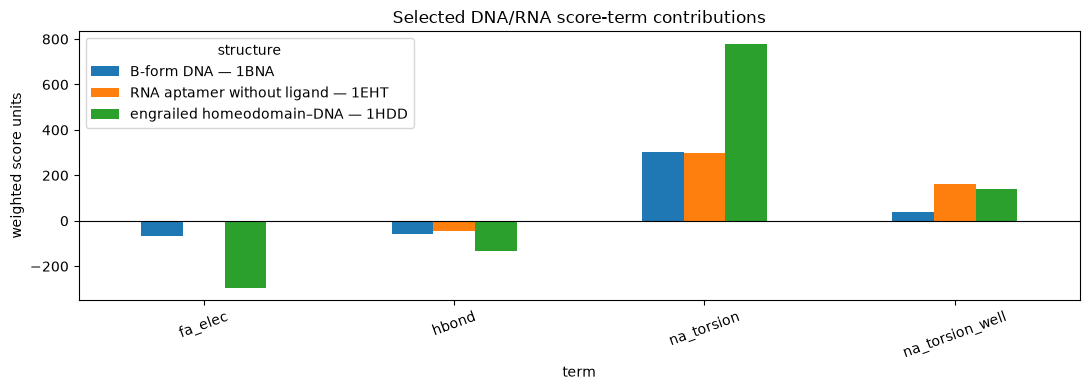

In [4]:
term_rows = []
for structure_label, pose in poses.items():
    scorer = score_function.render_whole_pose_scoring_module(pose)
    weighted = scorer(pose.coords, sum_terms=False, apply_weights=True)[:, 0]
    for score_type, value in zip(score_function.all_score_types(), weighted):
        term_rows.append(
            {
                "structure": structure_label,
                "term": score_type.name,
                "weighted_value": float(value.detach().cpu()),
            }
        )
term_frame = pd.DataFrame(term_rows)
na_active_terms = [
    "fa_ljatr",
    "fa_ljrep",
    "fa_lk",
    "fa_elec",
    "hbond",
    "lk_ball_iso",
    "lk_ball",
    "lk_bridge",
    "lk_bridge_uncpl",
    "cart_lengths",
    "cart_angles",
    "cart_torsions",
    "cart_hxltorsions",
    "na_torsion",
    "na_torsion_well",
]
na_inactive_terms = [
    "gen_torsions",
    "cart_impropers",
    "rama",
    "omega",
    "ref",
    "dunbrack_rot",
    "dunbrack_rotdev",
    "dunbrack_semirot",
]
na_only_structures = {
    "B-form DNA — 1BNA",
    "RNA aptamer without ligand — 1EHT",
}
expected_zero = term_frame[
    term_frame["structure"].isin(na_only_structures)
    & term_frame["term"].isin(na_inactive_terms)
]
assert np.allclose(expected_zero["weighted_value"], 0.0)
term_frame["NA-only expectation"] = np.where(
    term_frame["term"].isin(na_inactive_terms),
    "zero (no canonical-NA parameterization)",
    "parameterized / applicability-dependent",
)
key_terms = na_active_terms + na_inactive_terms
show_table(term_frame[term_frame["term"].isin(key_terms)])

plot_frame = term_frame[
    term_frame["term"].isin(["hbond", "fa_elec", "na_torsion", "na_torsion_well"])
].pivot(index="term", columns="structure", values="weighted_value")
ax = plot_frame.plot.bar(figsize=(11, 4))
ax.axhline(0, color="black", linewidth=0.8)
ax.set(ylabel="weighted score units", title="Selected DNA/RNA score-term contributions")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## Deposited geometry and DNA/RNA glycosidic-chi sampling

`NaChiRotamerSampler` reads the same fitted means and standard deviations used by the NA torsion score. DNA receives anti glycosidic-chi modes; RNA can additionally receive a syn mode when its fitted well is sufficiently favorable. Sugar pucker is read from the deposited input and is not changed by the current packer.

The next cell measures deposited chi from each residue type's declared `chi1` atoms and classifies the deposited sugar with the score model's documented soft `pucker_weights()`. It reports the dominant 0–9 pucker bin and total north-state weight, then compares sampled chi candidates with the deposited angle. TMol does not currently expose a stable high-level pseudorotation phase/amplitude analysis API, so this tutorial does not call the sampler's private `_pucker_for_blocks()` helper or present its discrete model bin as a crystallographic pseudorotation angle. RNA candidate counts can also include combinations with sampled hydroxyl-proton chis.

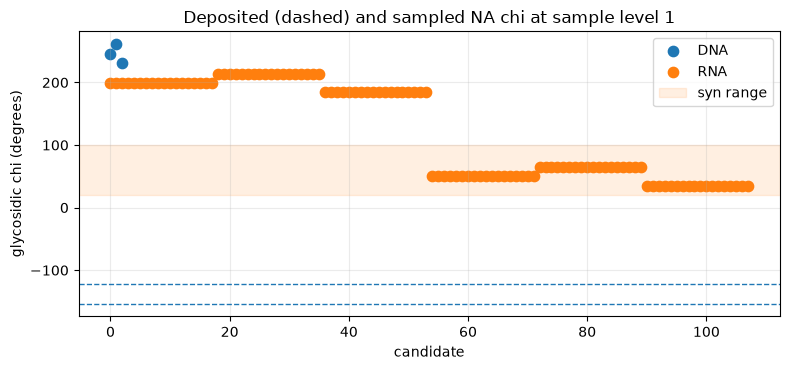

In [5]:
from tmol.numeric import coord_dihedrals
from tmol.score.na_torsion import (
    NORTH_PUCKERS,
    SYN_RANGE,
    pucker_weights,
    sugar_ring_atoms,
)


def deposited_na_geometry(pose, block_index, sampler):
    block_type = pose.block_type(0, block_index)
    offset = int(pose.block_coord_offset64[0, block_index])
    chi_atoms = [int(uaid[0]) for uaid in block_type.torsion_to_uaids["chi1"]]
    chi_xyz = pose.coords[0, offset + torch.tensor(chi_atoms, device=device)].double()
    deposited_chi = float(
        torch.rad2deg(
            coord_dihedrals(
                chi_xyz[0:1], chi_xyz[1:2], chi_xyz[2:3], chi_xyz[3:4]
            )[0]
        )
        .detach()
        .cpu()
    )
    ring_atoms = sugar_ring_atoms(block_type, ELEMENT_BY_ATOM_TYPE)
    if ring_atoms is None:
        raise RuntimeError(f"No complete sugar ring for block {block_index}")
    ring_xyz = pose.coords[
        0, offset + torch.tensor(ring_atoms, device=device)
    ].unsqueeze(0)
    weights = pucker_weights(ring_xyz, sampler.params.pucker_temperature)[0]
    return {
        "deposited_chi_degrees": deposited_chi,
        "deposited_chi_syn_range": bool(
            SYN_RANGE[0] <= deposited_chi % 360.0 <= SYN_RANGE[1]
        ),
        "dominant_deposited_pucker_bin": int(torch.argmax(weights).item()),
        "deposited_north_pucker_weight": float(
            weights[list(NORTH_PUCKERS)].sum().detach().cpu()
        ),
    }


def sampled_na_chis(label, pose, block_index):
    sampler = NaChiRotamerSampler.from_database(
        param_db, device, chi_sample_level=1, sample_syn=True
    )
    task = PackerTask(pose, PackerPalette())
    task.restrict_to_repacking()
    enabled = torch.zeros_like(pose.block_type_ind, dtype=torch.bool)
    enabled[:, block_index] = True
    task.disable_packing_by_block_mask(~enabled)
    task.add_conformer_sampler(sampler)
    set_task = SetPackerTask.from_packer_task(task)
    _, _, _, chis = sampler.sample_chi_for_poses(pose, set_task)
    values = chis[:, 0].detach().cpu().numpy()
    deposited = deposited_na_geometry(pose, block_index, sampler)
    offsets = (
        values - deposited["deposited_chi_degrees"] + 180.0
    ) % 360.0 - 180.0
    author_label = (
        f"{pose.pdb_info.chain_labels[0, block_index]}:"
        f"{pose.pdb_info.residue_labels[0, block_index]}"
        f"{pose.pdb_info.residue_insertion_codes[0, block_index]}"
    )
    return pd.DataFrame(
        {
            "polymer": label,
            "block_index": block_index,
            "author_label": author_label,
            "name3": pose.block_type(0, block_index).name3,
            "candidate": np.arange(len(values)),
            "candidate_chi_degrees": values,
            "candidate_minus_deposited_chi_degrees": offsets,
            "candidate_syn_range": (values >= SYN_RANGE[0]) & (values <= SYN_RANGE[1]),
            **deposited,
        }
    )


rotamer_frame = pd.concat(
    [
        sampled_na_chis("DNA", poses["B-form DNA — 1BNA"], 5),
        sampled_na_chis("RNA", poses["RNA aptamer without ligand — 1EHT"], 16),
    ],
    ignore_index=True,
)
show_table(
    rotamer_frame[
        [
            "polymer",
            "block_index",
            "author_label",
            "name3",
            "deposited_chi_degrees",
            "deposited_chi_syn_range",
            "dominant_deposited_pucker_bin",
            "deposited_north_pucker_weight",
        ]
    ].drop_duplicates()
)
show_table(rotamer_frame)
fig, ax = plt.subplots(figsize=(8, 3.8))
for label, values in rotamer_frame.groupby("polymer"):
    ax.scatter(
        values["candidate"], values["candidate_chi_degrees"], label=label, s=55
    )
    ax.axhline(
        values["deposited_chi_degrees"].iloc[0], linestyle="--", linewidth=1
    )
ax.axhspan(SYN_RANGE[0], SYN_RANGE[1], alpha=0.12, color="tab:orange", label="syn range")
ax.set(
    xlabel="candidate",
    ylabel="glycosidic chi (degrees)",
    title="Deposited (dashed) and sampled NA chi at sample level 1",
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Swap a Watson–Crick pair at a homeodomain–DNA recognition site

The engrailed homeodomain recognizes the internal TAAT subsite through a minor-groove N-terminal arm and a major-groove recognition helix. The workflow identifies which adenine at chain A residues 12–13 has the more favorable weighted protein–DNA `hbond` contribution. It then chooses an opposite-strand thymine by minimizing the **two-orientation** pair value `M[DA, DT] + M[DT, DA]`, rather than assuming a residue-number mapping. This score-based heuristic is not a general Watson–Crick base-pair detector; the named A–T distances below verify that it selects the intended deposited 1HDD pair. The comparison is the chemically matched pair swap DA·DT→DT·DA—not a single-strand mismatch.

For both pair identities, TMol rebuilds both nucleotides with `NaChiRotamerSampler`, repacks the same nearby protein side-chain shell, and Cartesian-minimizes a deliberately narrower atom mask: both bases and declared hydroxyl proton-chi hydrogens may move, while the sugar–phosphate atoms and protein main chain remain fixed. This avoids treating C1′, C2′, or O4′ as general Cartesian side-chain degrees of freedom.

The reported `target_pair_protein_hbond` and full `protein_DNA_interaction` sum both block-pair matrix orientations. `protein_DNA_favorable_hbond_block_pairs` is the full-interface count of DNA–protein residue pairs whose combined weighted `hbond` contribution is below −0.1; it is a residue-pair score count, not an atom-level hydrogen-bond count. Named A–T heavy-atom distances—A(N6)···T(O4) and A(N1)···T(N3)—supply direct Watson–Crick geometry diagnostics before and after Cartesian minimization. Interface distances/clash counts and covalent bond drift remain separate geometry checks.

> **Task restriction is intentional.** `restrict_identities_per_pose()` constructs one keep mask from `per_block_considered_block_types_is_orig`, replaces both pair positions in that mask, and intersects `per_block_is_block_type_allowed` exactly once. Every other position remains at its original identity. Do **not** call `restrict_to_repacking()` on this design task: that additional mask would remove the swapped identities. This helper narrows inspected `PackerTask` fields; it is not a built-in DNA-specificity protocol.

This is one low-sample local trajectory (`chi_sample_level=1`) sized for a documentation smoke test. On CUDA, repeated PyTorch seeds can probe search variability; on CPU the packer uses an unexposed C RNG, so outcomes are not controlled replicates. It illustrates one structural response, not converged specificity. Repeat independent packer runs before drawing conclusions.

In [6]:
homeodomain_pose = poses["engrailed homeodomain–DNA — 1HDD"]
DNA_NAMES = {"DA", "DC", "DG", "DT"}
dna_mask = block_mask_for_name3(homeodomain_pose, DNA_NAMES)
real_mask = homeodomain_pose.block_type_ind >= 0
protein_mask = real_mask & ~dna_mask

block_scorer = score_function.render_block_pair_scoring_module(homeodomain_pose)
by_term = block_scorer(
    homeodomain_pose.coords, sum_terms=False, apply_weights=True
)
hbond_index = score_function.all_score_types().index(ScoreType.hbond)
hbond_matrix = by_term[hbond_index, 0]
protein_blocks = torch.nonzero(protein_mask[0], as_tuple=False).flatten()
chain_labels = np.asarray(homeodomain_pose.pdb_info.chain_labels[0]).astype(str)
residue_labels = np.asarray(homeodomain_pose.pdb_info.residue_labels[0]).astype(str)
core_adenine_mask = (
    dna_mask[0]
    & block_mask_for_name3(homeodomain_pose, {"DA"})[0]
    & torch.as_tensor(
        (chain_labels == "A") & np.isin(residue_labels, ["12", "13"]),
        device=device,
    )
)
core_adenines = torch.nonzero(core_adenine_mask, as_tuple=False).flatten()
if len(core_adenines) != 2:
    raise RuntimeError("Expected the two adenines in the 1HDD TAAT subsite")
target_hbond_scores = torch.stack(
    [
        hbond_matrix[block_index, protein_blocks].sum()
        + hbond_matrix[protein_blocks, block_index].sum()
        for block_index in core_adenines
    ]
)
target_block = int(core_adenines[torch.argmin(target_hbond_scores)].item())
target_name3 = homeodomain_pose.block_type(0, target_block).name3
target_chain = str(homeodomain_pose.pdb_info.chain_labels[0, target_block])
target_residue = str(homeodomain_pose.pdb_info.residue_labels[0, target_block])
if target_name3 != "DA":
    raise RuntimeError(f"Expected target DA, found {target_name3}")

opposite_thymine_mask = (
    dna_mask[0]
    & block_mask_for_name3(homeodomain_pose, {"DT"})[0]
    & torch.as_tensor(chain_labels != target_chain, device=device)
)
opposite_thymines = torch.nonzero(
    opposite_thymine_mask, as_tuple=False
).flatten()
if len(opposite_thymines) == 0:
    raise RuntimeError("No opposite-strand DT candidates were found")
target_to_thymine_hbond = (
    hbond_matrix[target_block, opposite_thymines]
    + hbond_matrix[opposite_thymines, target_block]
)
paired_block = int(
    opposite_thymines[torch.argmin(target_to_thymine_hbond)].item()
)
paired_name3 = homeodomain_pose.block_type(0, paired_block).name3
paired_chain = str(homeodomain_pose.pdb_info.chain_labels[0, paired_block])
paired_residue = str(homeodomain_pose.pdb_info.residue_labels[0, paired_block])
assert paired_name3 == "DT" and paired_chain != target_chain
paired_hbond_score = float(target_to_thymine_hbond.min().detach().cpu())
print(
    f"selected pair: block {target_block} chain {target_chain} residue "
    f"{target_residue} {target_name3} · block {paired_block} chain "
    f"{paired_chain} residue {paired_residue} {paired_name3}; "
    f"two-orientation pair hbond {paired_hbond_score:.3f}"
)

centroids, radii = compute_block_centroids_and_furthest_dist(homeodomain_pose)
adjacency = compute_block_adjacency(centroids, radii)
local_blocks = (
    adjacency[:, target_block] | adjacency[:, paired_block]
).clone()
local_blocks[:, target_block] = True
local_blocks[:, paired_block] = True
local_protein_blocks = local_blocks & protein_mask
show_table(
    pd.DataFrame(
        [
            {
                "target_DA": f"{target_chain}:{target_residue}",
                "paired_DT": f"{paired_chain}:{paired_residue}",
                "pair_selection_metric": "two-orientation weighted hbond",
                "pair_hbond_score": paired_hbond_score,
                "shared_nearby_protein_blocks": int(local_protein_blocks.sum()),
            }
        ]
    )
)

selected pair: block 12 chain A residue 13 DA · block 30 chain B residue 31 DT; two-orientation pair hbond -2.560


In [7]:
def restrict_identities_per_pose(task, requested_names_by_block):
    """Apply all per-pose identity requests in one monotonic intersection."""
    keep = task.per_block_considered_block_types_is_orig.detach().clone()
    considered = task.per_block_considered_block_types
    for block_index, names in requested_names_by_block.items():
        if len(names) != task.per_block_is_block_type_allowed.shape[0]:
            raise ValueError("Each identity list must contain one name per pose")
        for pose_index, name3 in enumerate(names):
            considered_here = considered[
                pose_index, block_index
            ].detach().cpu().tolist()
            requested = torch.tensor(
                [
                    index >= 0
                    and task.pbt.active_block_types[index].name3 == name3
                    for index in considered_here
                ],
                dtype=torch.bool,
                device=task.device,
            )
            if not torch.any(requested):
                raise ValueError(
                    f"{name3} is not available at block {block_index}"
                )
            keep[pose_index, block_index] = requested
    task.per_block_is_block_type_allowed = torch.logical_and(
        task.per_block_is_block_type_allowed, keep
    )


def add_protein_and_na_samplers(task):
    task.add_conformer_sampler(
        create_dunbrack_sampler_from_database(param_db, device)
    )
    task.add_conformer_sampler(FixedAAChiSampler())
    task.add_conformer_sampler(
        NaChiRotamerSampler.from_database(param_db, device, chi_sample_level=1)
    )
    task.add_conformer_sampler(IncludeCurrentSampler())


variant_labels = ["DA·DT", "DT·DA"]
target_variants = ["DA", "DT"]
paired_variants = ["DT", "DA"]
mutation_batch = PoseStackBuilder.from_poses(
    [homeodomain_pose] * len(variant_labels), device
)
mutation_task = PackerTask(mutation_batch, PackerPalette())
restrict_identities_per_pose(
    mutation_task,
    {
        target_block: target_variants,
        paired_block: paired_variants,
    },
)
# Do not call restrict_to_repacking(): it would intersect away swapped identities.
non_pair = torch.ones(
    mutation_batch.max_n_blocks, dtype=torch.bool, device=device
)
non_pair[[target_block, paired_block]] = False
assert torch.equal(
    mutation_task.per_block_is_block_type_allowed[:, non_pair],
    mutation_task.per_block_considered_block_types_is_orig[:, non_pair],
)
for block_index, requested_names in {
    target_block: target_variants,
    paired_block: paired_variants,
}.items():
    for pose_index, requested_name3 in enumerate(requested_names):
        considered = mutation_task.per_block_considered_block_types[
            pose_index, block_index
        ]
        allowed = mutation_task.per_block_is_block_type_allowed[
            pose_index, block_index
        ]
        allowed_name3s = {
            mutation_task.pbt.active_block_types[int(block_type_index)].name3
            for block_type_index in considered[allowed].detach().cpu().tolist()
            if block_type_index >= 0
        }
        assert allowed_name3s == {requested_name3}

local_design_region = local_protein_blocks.clone()
local_design_region[:, target_block] = True
local_design_region[:, paired_block] = True
packing_region = local_design_region.expand(len(variant_labels), -1).clone()
mutation_task.disable_packing_by_block_mask(~packing_region)
add_protein_and_na_samplers(mutation_task)

torch.manual_seed(SEED)
packed_variants = pack_rotamers(mutation_batch, score_function, mutation_task)

# Minimize both bases/proton-chi atoms plus the same nearby protein shell.
# The nucleotide sugar-phosphates and protein main chain remain fixed.
pair_by_pose = torch.zeros_like(
    packed_variants.block_type_ind, dtype=torch.bool
)
pair_by_pose[:, target_block] = True
pair_by_pose[:, paired_block] = True
protein_region = local_protein_blocks.expand(len(variant_labels), -1)
na_coord_mask = build_na_base_and_proton_chi_coord_mask(
    packed_variants, pair_by_pose
)
protein_coord_mask = build_sidechain_coord_mask(
    packed_variants
) & res_mask_to_coord_mask(packed_variants, protein_region)
coord_mask = na_coord_mask | protein_coord_mask
show_table(
    pd.DataFrame(
        {
            "pair_identity": variant_labels,
            "movable_pair_base_and_proton_chi_atoms": na_coord_mask.sum(dim=1)
            .detach()
            .cpu()
            .numpy(),
            "movable_shared_protein_sidechain_atoms": protein_coord_mask.sum(dim=1)
            .detach()
            .cpu()
            .numpy(),
            "Cartesian_movable_atoms_total": coord_mask.sum(dim=1)
            .detach()
            .cpu()
            .numpy(),
        }
    )
)
try:
    dna_scope_viewer = tmol.view(
        packed_variants.split(0),
        highlighted=coord_mask[0, packed_variants.real_atoms[0]],
        highlight_color="#7b2cbf",
    )
    dna_scope_viewer.show()
except ImportError:
    print("Install py3Dmol to inspect the DNA refinement mask.")

refined_variants = run_cart_min(
    packed_variants,
    score_function,
    coord_mask=coord_mask,
    optimizer_kwargs={"max_iter": 30},
)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

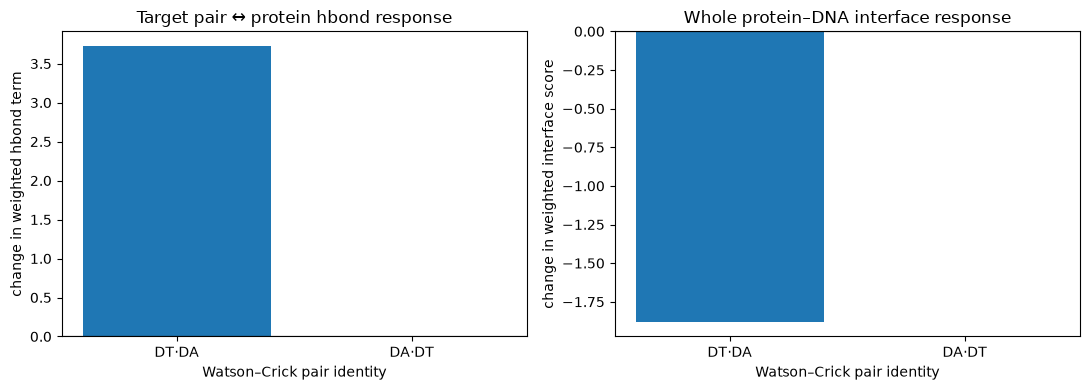

In [8]:
def protein_dna_metrics(pose, target_pair_indices):
    dna = block_mask_for_name3(pose, DNA_NAMES)[0]
    real = pose.block_type_ind[0] >= 0
    protein = real & ~dna
    scorer = score_function.render_block_pair_scoring_module(pose)
    term_matrices = scorer(pose.coords, sum_terms=False, apply_weights=True)[:, 0]
    hbond = term_matrices[hbond_index]
    total = term_matrices.sum(dim=0)
    dna_indices = torch.nonzero(dna, as_tuple=False).flatten()
    protein_indices = torch.nonzero(protein, as_tuple=False).flatten()
    target_pair_indices = torch.as_tensor(
        target_pair_indices, dtype=torch.long, device=pose.device
    )
    pair_hbond = hbond[dna_indices[:, None], protein_indices[None, :]]
    pair_hbond = pair_hbond + hbond[
        protein_indices[:, None], dna_indices[None, :]
    ].T
    cross_total = total[dna_indices[:, None], protein_indices[None, :]].sum()
    cross_total += total[
        protein_indices[:, None], dna_indices[None, :]
    ].sum()
    target_pair_hbond = hbond[
        target_pair_indices[:, None], protein_indices[None, :]
    ].sum()
    target_pair_hbond += hbond[
        protein_indices[:, None], target_pair_indices[None, :]
    ].sum()
    whole_scorer = score_function.render_whole_pose_scoring_module(pose)
    return {
        "total_score": float(whole_scorer(pose.coords).detach().cpu()[0]),
        "protein_DNA_interaction": float(cross_total.detach().cpu()),
        "protein_DNA_hbond": float(pair_hbond.sum().detach().cpu()),
        "target_pair_protein_hbond": float(target_pair_hbond.detach().cpu()),
        "protein_DNA_favorable_hbond_block_pairs": int(
            (pair_hbond < -0.1).sum().detach().cpu()
        ),
    }


def watson_crick_distances(pose):
    pair_names = {
        target_block: pose.block_type(0, target_block).name3,
        paired_block: pose.block_type(0, paired_block).name3,
    }
    adenine_blocks = [
        block for block, name3 in pair_names.items() if name3 == "DA"
    ]
    thymine_blocks = [
        block for block, name3 in pair_names.items() if name3 == "DT"
    ]
    if len(adenine_blocks) != 1 or len(thymine_blocks) != 1:
        raise RuntimeError(f"Expected one DA and one DT, found {pair_names}")
    adenine_block = adenine_blocks[0]
    thymine_block = thymine_blocks[0]
    return {
        "A_N6_donor_to_T_O4_acceptor_A": named_atom_distance(
            pose, adenine_block, "N6", thymine_block, "O4"
        ),
        "A_N1_acceptor_to_T_N3_donor_A": named_atom_distance(
            pose, adenine_block, "N1", thymine_block, "N3"
        ),
    }


variant_poses = {}
variant_rows = []
watson_crick_rows = []
for pose_index, variant_label in enumerate(variant_labels):
    packed_variant = packed_variants.split(pose_index)
    variant_pose = refined_variants.split(pose_index)
    variant_poses[variant_label] = variant_pose
    assert packed_variant.block_type(0, target_block).name3 == target_variants[
        pose_index
    ]
    assert packed_variant.block_type(0, paired_block).name3 == paired_variants[
        pose_index
    ]
    for stage, pose in (
        ("packed; before Cartesian minimization", packed_variant),
        ("after Cartesian minimization", variant_pose),
    ):
        watson_crick_rows.append(
            {
                "pair_identity": variant_label,
                "stage": stage,
                **watson_crick_distances(pose),
            }
        )
    variant_dna = block_mask_for_name3(variant_pose, DNA_NAMES)
    variant_protein = (variant_pose.block_type_ind >= 0) & ~variant_dna
    geometry = interface_geometry_diagnostics(
        variant_pose, variant_dna, variant_protein
    )
    geometry.update(
        bond_length_change_diagnostics(
            packed_variant,
            variant_pose,
            coord_mask[pose_index : pose_index + 1],
        )
    )
    variant_rows.append(
        {
            "pair_identity": variant_label,
            **protein_dna_metrics(
                variant_pose, [target_block, paired_block]
            ),
            **geometry,
        }
    )

watson_crick_frame = pd.DataFrame(watson_crick_rows)
show_table(watson_crick_frame)

mutation_frame = pd.DataFrame(variant_rows)
reference = mutation_frame.loc[
    mutation_frame["pair_identity"] == "DA·DT"
].iloc[0]
for metric in (
    "total_score",
    "protein_DNA_interaction",
    "protein_DNA_hbond",
    "target_pair_protein_hbond",
):
    mutation_frame[f"delta_{metric}"] = mutation_frame[metric] - reference[metric]
if mutation_frame["delta_total_score"].abs().max() > 100:
    raise RuntimeError(
        "The local refinement changed the total score by more than 100 units; "
        "inspect the model before interpreting interface metrics."
    )
mutation_frame["score_sanity_check"] = "passed"
mutation_frame = mutation_frame.sort_values(
    "delta_target_pair_protein_hbond", ascending=False
)
show_table(mutation_frame)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(
    mutation_frame["pair_identity"],
    mutation_frame["delta_target_pair_protein_hbond"],
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(
    xlabel="Watson–Crick pair identity",
    ylabel="change in weighted hbond term",
    title="Target pair ↔ protein hbond response",
)
axes[1].bar(
    mutation_frame["pair_identity"],
    mutation_frame["delta_protein_DNA_interaction"],
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set(
    xlabel="Watson–Crick pair identity",
    ylabel="change in weighted interface score",
    title="Whole protein–DNA interface response",
)
plt.tight_layout()
plt.show()

display(
    tmol.switchable_view(
        variant_poses,
        notes={
            row["pair_identity"]: (
                f"pair/protein hbond Δ "
                f"{row['delta_target_pair_protein_hbond']:+.3f}; "
                f"interface Δ {row['delta_protein_DNA_interaction']:+.3f}"
            )
            for _, row in mutation_frame.iterrows()
        },
    )
)

**Expected observations.** Positive hbond or interface deltas mean that the swapped, locally refined pair is less favorable than the equivalently refined starting pair under the displayed TMol score component. This single seeded comparison makes one structural response visible; it does not establish specificity, convergence, or an uncertainty interval. Repeat independent seeds and, where appropriate, starting structures before interpreting a sequence preference.

## RNA aptamer with a fixed small molecule

The 1EHT CIF contains explicit TEP chemical-component bonds and hydrogens. `prepare_ligands=True` creates ligand parameters and returns the extended database in the build context. The ligand is disabled in the `PackerTask`: only nearby RNA blocks receive low-level NA chi candidates. Cartesian minimization uses the same explicit base/proton-chi mask as the DNA example, fixing the RNA sugar–phosphate heavy atoms and sugar-bound carbon hydrogens. Theophylline coordinates remain fixed throughout this CPU-practical, single-seed example, and the code retains a direct coordinate assertion.

The deposited 1EHT binding-site annotation names residues U6, A7, C8, C22, U24, and A28. The final table finds each annotated residue's nearest named **base** heavy-atom contact to TEP in the input, then measures that **same atom pair** after refinement. This is a concise recognition-pocket motif check using available atom names; it is not an invented hydrogen-bond classifier or a ligand-pose sampling claim. Interface heavy-atom contacts and covalent bond-length drift provide additional geometry diagnostics alongside the scores.

In [9]:
from openbabel import openbabel as ob

aptamer_array = atom_arrays["theophylline RNA aptamer — 1EHT"]
openbabel_output_level = ob.obErrorLog.GetOutputLevel()
ob.obErrorLog.SetOutputLevel(ob.obError)
try:
    aptamer_pose, aptamer_context = build_pose(
        aptamer_array, prepare_ligands=True, return_context=True
    )
finally:
    ob.obErrorLog.SetOutputLevel(openbabel_output_level)
aptamer_sfxn = beta2016_score_function(
    device, param_db=aptamer_context.parameter_database
)
ligand_mask = block_mask_for_name3(aptamer_pose, {"TEP"})
rna_mask = block_mask_for_name3(aptamer_pose, {"A", "C", "G", "U"})
if int(ligand_mask.sum()) != 1:
    raise RuntimeError("Expected exactly one TEP ligand block")
ligand_block = int(torch.nonzero(ligand_mask[0], as_tuple=False)[0])

centroids, radii = compute_block_centroids_and_furthest_dist(aptamer_pose)
aptamer_adjacency = compute_block_adjacency(centroids, radii)
pocket_rna = aptamer_adjacency[:, ligand_block] & rna_mask

aptamer_task = PackerTask(aptamer_pose, PackerPalette())
aptamer_task.restrict_to_repacking()
aptamer_task.disable_packing_by_block_mask(~pocket_rna)
aptamer_task.add_conformer_sampler(
    NaChiRotamerSampler.from_database(
        aptamer_context.parameter_database,
        device,
        chi_sample_level=1,
        sample_syn=True,
    )
)
aptamer_task.add_conformer_sampler(IncludeCurrentSampler())

torch.manual_seed(SEED)
packed_aptamer = pack_rotamers(aptamer_pose, aptamer_sfxn, aptamer_task)
aptamer_coord_mask = build_na_base_and_proton_chi_coord_mask(
    packed_aptamer, pocket_rna
)
movable_ligand_atoms = int(
    (
        aptamer_coord_mask
        & res_mask_to_coord_mask(packed_aptamer, ligand_mask)
    )
    .sum()
    .item()
)
assert movable_ligand_atoms == 0
show_table(
    pd.DataFrame(
        [
            {
                "RNA_pocket_blocks": int(pocket_rna.sum().item()),
                "Cartesian_movable_RNA_base_and_proton_chi_atoms": int(
                    aptamer_coord_mask.sum().item()
                ),
                "movable_ligand_atoms": movable_ligand_atoms,
            }
        ]
    )
)
try:
    aptamer_scope_viewer = tmol.view(
        packed_aptamer,
        highlighted=aptamer_coord_mask[0, packed_aptamer.real_atoms[0]],
        highlight_color="#7b2cbf",
    )
    aptamer_scope_viewer.show()
except ImportError:
    print("Install py3Dmol to inspect the RNA refinement mask.")

refined_aptamer = run_cart_min(
    packed_aptamer,
    aptamer_sfxn,
    coord_mask=aptamer_coord_mask,
    optimizer_kwargs={"max_iter": 10},
)


def ligand_rna_metrics(pose):
    ligand = block_mask_for_name3(pose, {"TEP"})[0]
    rna = block_mask_for_name3(pose, {"A", "C", "G", "U"})[0]
    scorer = aptamer_sfxn.render_block_pair_scoring_module(pose)
    matrices = scorer(pose.coords, sum_terms=False, apply_weights=True)[:, 0]
    hb_index = aptamer_sfxn.all_score_types().index(ScoreType.hbond)
    ligand_indices = torch.nonzero(ligand, as_tuple=False).flatten()
    rna_indices = torch.nonzero(rna, as_tuple=False).flatten()
    total = matrices.sum(dim=0)
    interaction = total[ligand_indices[:, None], rna_indices[None, :]].sum()
    interaction += total[rna_indices[:, None], ligand_indices[None, :]].sum()
    hbond = matrices[hb_index]
    hbond_interaction = hbond[ligand_indices[:, None], rna_indices[None, :]].sum()
    hbond_interaction += hbond[rna_indices[:, None], ligand_indices[None, :]].sum()
    return float(interaction.detach().cpu()), float(hbond_interaction.detach().cpu())


interaction_before, hbond_before = ligand_rna_metrics(aptamer_pose)
interaction_after, hbond_after = ligand_rna_metrics(refined_aptamer)
ligand_coord_mask = res_mask_to_coord_mask(aptamer_pose, ligand_mask)
ligand_coords_before = aptamer_pose.coords[ligand_coord_mask]
ligand_coords_after = refined_aptamer.coords[ligand_coord_mask]
ligand_motion = float(
    torch.linalg.vector_norm(ligand_coords_after - ligand_coords_before, dim=-1)
    .max()
    .detach()
    .cpu()
)
if ligand_motion > 1e-3:
    raise RuntimeError(
        f"The fixed TEP ligand moved by {ligand_motion:.6f} Å; check the coordinate mask"
    )
input_geometry = interface_geometry_diagnostics(
    aptamer_pose, ligand_mask, rna_mask
)
refined_geometry = interface_geometry_diagnostics(
    refined_aptamer, ligand_mask, rna_mask
)
bond_geometry = bond_length_change_diagnostics(
    aptamer_pose, refined_aptamer, aptamer_coord_mask
)

# The deposited _struct_site_gen table names these six recognition-pocket residues.
recognition_site = {
    "6": "U",
    "7": "A",
    "8": "C",
    "22": "C",
    "24": "U",
    "28": "A",
}
aptamer_chain_labels = np.asarray(
    aptamer_pose.pdb_info.chain_labels[0]
).astype(str)
aptamer_residue_labels = np.asarray(
    aptamer_pose.pdb_info.residue_labels[0]
).astype(str)
aptamer_elements = {
    atom_type.name: atom_type.element
    for atom_type in aptamer_context.parameter_database.chemical.atom_types
}
ligand_heavy_names = [
    atom.name
    for atom in aptamer_pose.block_type(0, ligand_block).atoms
    if aptamer_elements.get(atom.atom_type) != "H"
]
recognition_contact_rows = []
for residue_label, expected_name3 in recognition_site.items():
    candidates = torch.nonzero(
        rna_mask[0]
        & torch.as_tensor(
            (aptamer_chain_labels == "A")
            & (aptamer_residue_labels == residue_label),
            device=device,
        ),
        as_tuple=False,
    ).flatten()
    if len(candidates) != 1:
        raise RuntimeError(
            f"Expected one annotated RNA residue A:{residue_label}"
        )
    rna_block = int(candidates[0])
    observed_name3 = aptamer_pose.block_type(0, rna_block).name3
    if observed_name3 != expected_name3:
        raise RuntimeError(
            f"A:{residue_label} is {observed_name3}, expected {expected_name3}"
        )
    rna_heavy_names = [
        atom.name
        for atom in aptamer_pose.block_type(0, rna_block).atoms
        if aptamer_elements.get(atom.atom_type) != "H"
        and "'" not in atom.name
        and atom.name != "P"
        and not atom.name.startswith("OP")
        and not (atom.name.startswith("O") and atom.name.endswith("P"))
    ]
    if not rna_heavy_names:
        raise RuntimeError(f"No named base heavy atoms for A:{residue_label}")
    named_pairs = [
        (
            named_atom_distance(
                aptamer_pose,
                rna_block,
                rna_atom,
                ligand_block,
                ligand_atom,
            ),
            rna_atom,
            ligand_atom,
        )
        for rna_atom in rna_heavy_names
        for ligand_atom in ligand_heavy_names
    ]
    input_distance, rna_atom, ligand_atom = min(named_pairs)
    refined_distance = named_atom_distance(
        refined_aptamer,
        rna_block,
        rna_atom,
        ligand_block,
        ligand_atom,
    )
    recognition_contact_rows.append(
        {
            "annotated_RNA_residue": (
                f"A:{residue_label} {observed_name3}"
            ),
            "RNA_atom": rna_atom,
            "TEP_atom": ligand_atom,
            "input_distance_A": input_distance,
            "refined_same_pair_distance_A": refined_distance,
            "input_direct_contact_le_4A": input_distance <= 4.0,
        }
    )
recognition_contact_frame = pd.DataFrame(recognition_contact_rows)
show_table(recognition_contact_frame)

aptamer_frame = pd.DataFrame(
    [
        {
            "stage": "input",
            "RNA_TEP_interaction": interaction_before,
            "RNA_TEP_hbond": hbond_before,
            "max_ligand_motion_A": 0.0,
            **input_geometry,
            "bond_length_RMS_change_from_input_A": 0.0,
            "maximum_absolute_bond_length_change_from_input_A": 0.0,
        },
        {
            "stage": "RNA repacked + minimized; TEP fixed",
            "RNA_TEP_interaction": interaction_after,
            "RNA_TEP_hbond": hbond_after,
            "max_ligand_motion_A": ligand_motion,
            **refined_geometry,
            "bond_length_RMS_change_from_input_A": bond_geometry[
                "bond_length_RMS_change_A"
            ],
            "maximum_absolute_bond_length_change_from_input_A": bond_geometry[
                "maximum_absolute_bond_length_change_A"
            ],
        },
    ]
)
show_table(aptamer_frame)
display(
    tmol.switchable_view(
        {"input aptamer": aptamer_pose, "refined RNA pocket": refined_aptamer},
        notes={
            "input aptamer": f"RNA–TEP interaction {interaction_before:.3f}",
            "refined RNA pocket": (
                f"RNA–TEP interaction {interaction_after:.3f}; "
                f"max ligand motion {ligand_motion:.6f} Å"
            ),
        },
    )
)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Conformational uncertainty across the complete 1EHT NMR ensemble

The deposited 1EHT entry contains ten models with identical chemistry. Model 1 above supports a controlled local-refinement example; the experiment below asks a different question by scoring all ten deposited starting conformations without refinement. The first pose reuses `aptamer_pose`, and models 2–10 reuse its ligand-aware build context. One `PoseStack` and one rendered block-pair scorer expose conformational variation without repeating ligand preparation.

The table reports both-orientation RNA–TEP interaction and hbond scores, the closest recognition-pocket heavy-atom distance, and the number of recognition-pocket/ligand heavy-atom pairs within 4 Å. NMR model number is an ensemble label, not a time coordinate or statistical weight.


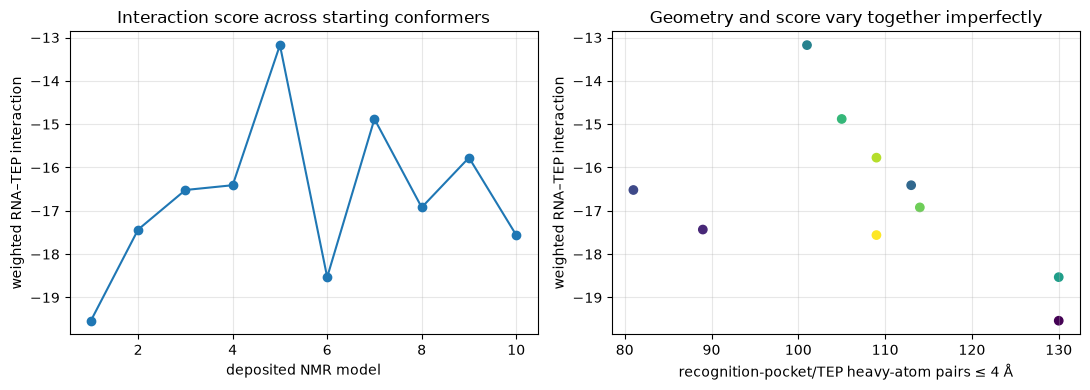

In [10]:
aptamer_ensemble_arrays = load_structure(
    str(cif_paths["theophylline RNA aptamer — 1EHT"]),
    include_bonds=True,
)
if aptamer_ensemble_arrays.stack_depth() != 10:
    raise RuntimeError("Expected ten deposited 1EHT NMR models")
ensemble_poses = [aptamer_pose]
for model_index in range(1, aptamer_ensemble_arrays.stack_depth()):
    diagnostics = StringIO()
    try:
        with redirect_stdout(diagnostics), redirect_stderr(diagnostics):
            ensemble_poses.append(
                pose_stack_from_biotite(
                    aptamer_ensemble_arrays[model_index],
                    device,
                    context=aptamer_context,
                    no_optH=True,
                )
            )
    except Exception:
        print(diagnostics.getvalue())
        raise

aptamer_ensemble = PoseStackBuilder.from_poses(ensemble_poses, device)
ensemble_ligand = block_mask_for_name3(aptamer_ensemble, {"TEP"})
ensemble_rna = block_mask_for_name3(aptamer_ensemble, {"A", "C", "G", "U"})
ensemble_pair_mask = (ensemble_ligand[:, :, None] & ensemble_rna[:, None, :]) | (
    ensemble_rna[:, :, None] & ensemble_ligand[:, None, :]
)
ensemble_scorer = aptamer_sfxn.render_block_pair_scoring_module(aptamer_ensemble)
with torch.no_grad():
    ensemble_matrices = ensemble_scorer(
        aptamer_ensemble.coords,
        sum_terms=False,
        apply_weights=True,
    )
ensemble_interactions = (ensemble_matrices.sum(dim=0) * ensemble_pair_mask).sum(
    dim=(1, 2)
)
ensemble_hbond_index = aptamer_sfxn.all_score_types().index(ScoreType.hbond)
ensemble_hbonds = (ensemble_matrices[ensemble_hbond_index] * ensemble_pair_mask).sum(
    dim=(1, 2)
)

ensemble_elements = {
    atom_type.name: atom_type.element
    for atom_type in aptamer_context.parameter_database.chemical.atom_types
}


def heavy_coordinate_indices(pose, pose_index, block_mask):
    """Return coordinate indices for heavy atoms in selected blocks."""
    indices = []
    pose_block_mask = (
        block_mask[pose_index] if block_mask.ndim == 2 else block_mask
    )
    for block_index in (
        torch.nonzero(pose_block_mask, as_tuple=False).flatten().tolist()
    ):
        block_type = pose.block_type(pose_index, block_index)
        offset = int(pose.block_coord_offset64[pose_index, block_index])
        indices.extend(
            offset + atom_index
            for atom_index, atom in enumerate(block_type.atoms)
            if ensemble_elements.get(atom.atom_type) != "H"
        )
    return torch.as_tensor(indices, device=device, dtype=torch.long)


ensemble_rows = []
recognition_labels = set(recognition_site)
for pose_index in range(aptamer_ensemble.n_poses):
    chain_labels = np.asarray(
        aptamer_ensemble.pdb_info.chain_labels[pose_index]
    ).astype(str)
    residue_labels = np.asarray(
        aptamer_ensemble.pdb_info.residue_labels[pose_index]
    ).astype(str)
    recognition_blocks = ensemble_rna[pose_index] & torch.as_tensor(
        (chain_labels == "A") & np.isin(residue_labels, list(recognition_labels)),
        device=device,
    )
    ligand_indices = heavy_coordinate_indices(
        aptamer_ensemble, pose_index, ensemble_ligand
    )
    pocket_indices = heavy_coordinate_indices(
        aptamer_ensemble, pose_index, recognition_blocks
    )
    distances = torch.cdist(
        aptamer_ensemble.coords[pose_index, ligand_indices],
        aptamer_ensemble.coords[pose_index, pocket_indices],
    )
    ensemble_rows.append(
        {
            "NMR_model": pose_index + 1,
            "RNA_TEP_interaction": float(
                ensemble_interactions[pose_index].detach().cpu()
            ),
            "RNA_TEP_hbond": float(ensemble_hbonds[pose_index].detach().cpu()),
            "closest_recognition_pocket_heavy_distance_A": float(
                distances.min().detach().cpu()
            ),
            "recognition_pocket_heavy_pairs_le_4A": int(
                (distances <= 4.0).sum().item()
            ),
        }
    )

ensemble_frame = pd.DataFrame(ensemble_rows)
show_table(ensemble_frame)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(
    ensemble_frame["NMR_model"],
    ensemble_frame["RNA_TEP_interaction"],
    marker="o",
)
axes[0].set(
    xlabel="deposited NMR model",
    ylabel="weighted RNA–TEP interaction",
    title="Interaction score across starting conformers",
)
axes[1].scatter(
    ensemble_frame["recognition_pocket_heavy_pairs_le_4A"],
    ensemble_frame["RNA_TEP_interaction"],
    c=ensemble_frame["NMR_model"],
    cmap="viridis",
)
axes[1].set(
    xlabel="recognition-pocket/TEP heavy-atom pairs ≤ 4 Å",
    ylabel="weighted RNA–TEP interaction",
    title="Geometry and score vary together imperfectly",
)
for axis in axes:
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

lowest_model = int(ensemble_frame["RNA_TEP_interaction"].idxmin())
highest_model = int(ensemble_frame["RNA_TEP_interaction"].idxmax())
distance_from_median = (
    ensemble_frame["RNA_TEP_interaction"]
    - ensemble_frame["RNA_TEP_interaction"].median()
).abs()
middle_model = int(distance_from_median.idxmin())
selected_models = list(dict.fromkeys([lowest_model, middle_model, highest_model]))
display(
    tmol.switchable_view(
        {
            f"NMR model {index + 1}": aptamer_ensemble.split(index)
            for index in selected_models
        },
        notes={
            f"NMR model {index + 1}": (
                f"RNA–TEP interaction "
                f"{ensemble_frame.loc[index, 'RNA_TEP_interaction']:.3f}; "
                f"contacts ≤4 Å "
                f"{ensemble_frame.loc[index, 'recognition_pocket_heavy_pairs_le_4A']}"
            )
            for index in selected_models
        },
    )
)

**Expected observations.** The ten deposited conformers need not have identical contacts or scores even though their sequence and parameterization match. A favorable interaction value can coexist with a different contact count because the score includes more than distance-threshold contacts. This ensemble measures sensitivity to deposited starting conformations; it is not a Boltzmann ensemble, uncertainty interval for refinement, or ligand-affinity prediction.


## Rosetta and PyRosetta comparison

Rosetta has protocol layers beyond the primitives demonstrated here: RosettaDNA base-pair mutation/design machinery, specialized RNA score functions and fragment assembly, FARFAR/FARFAR2, stepwise modeling, RNA threading, and docking. TMol currently provides canonical DNA/RNA chemistry, the combined NA torsion model, NA chi rotamers, all-atom scoring, packing, and generic Cartesian/kinematic minimization in a batched PyTorch representation.

Two implementation details matter when translating a Rosetta workflow:

- The TMol NA packer changes glycosidic chi and sampled hydroxyl proton chis. It reads sugar pucker from the input rather than sampling pucker, so it is not a complete nucleotide conformational search. The explicit Cartesian masks above move base/proton-chi atoms while fixing sugar–phosphate atoms; they do not perform discrete pucker sampling.
- The protein–DNA pair-swap and model-1 aptamer refinement are single-seed, local, fixed-sugar–phosphate calculations. The separate ten-model aptamer analysis measures sensitivity to deposited starting conformations without refining them. Its NMR models are not statistical replicates. None of these examples invokes RosettaDNA specificity optimization, RNA fragment assembly, docking, or ligand-pose sampling.

The closest PyRosetta starting point is [14.00 RNA Basics](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/14.00-RNA-Basics.ipynb). For broader Rosetta scoring context, the [Rosetta scoring tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/scoring/scoring) and [Rosetta Energy Function workshop slides](https://meilerlab.org/wp-content/uploads/2023/12/Rosetta_Energy_Function.pdf) explain the weighted-term model and Rosetta's specialized score-function families. The [Rosetta-to-TMol crosswalk](rosetta_crosswalk.md) records which analogies stop at these lower-level primitives.

## Where to go next

This completes the core API Tutorials. Continue to [Case Study 09 — Map and Test a Protein Interface](09_protein_interface_hotspot_scan.ipynb) or [Case Study 10 — Ligand Pose Sensitivity and Local Rescue](10_ligand_pose_sensitivity.ipynb) for integrated scientific questions, or use the [Task index](recipe_index.md) for concise lookup.

## Exercises

1. Change the homeodomain target from the strongest protein-hbond-scored adenine to the next-ranked site, identify its paired thymine with the same two-orientation rule, and compare pair swaps.
2. On CUDA, repeat three PyTorch packer seeds at `chi_sample_level=1`; then expand the level only if runtime permits, reporting candidate count, runtime, interface-score spread, and Watson–Crick distance spread. On CPU, do not treat different torch seeds as controlled replicates because the packer uses an unexposed C RNG.
3. Keep both DNA identities fixed and repack only the same nearby protein shell to separate sequence and conformational effects.
4. In the aptamer, vary the RNA-pocket definition while asserting that TEP coordinates and the named recognition-pocket atom pairs remain unchanged.
5. Locally refine all ten 1EHT models with one matched protocol, then compare the input ensemble spread with the endpoint spread without treating models as statistical replicates.

## References

- [Rosetta-to-TMol crosswalk](rosetta_crosswalk.md)
- Kissinger et al., [Crystal structure of an engrailed homeodomain–DNA complex](https://doi.org/10.1016/0092-8674(90)90453-L)
- Zimmermann et al., [Interlocking structural motifs mediate molecular discrimination by a theophylline-binding RNA](https://doi.org/10.1038/nsb0897-644)
- [RCSB 1HDD](https://www.rcsb.org/structure/1HDD) and [RCSB 1EHT](https://www.rcsb.org/structure/1EHT)
- [PyRosetta RNA Basics](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/14.00-RNA-Basics.ipynb)
- [Rosetta additional energy terms, including DNA/RNA terms](https://docs.rosettacommons.org/docs/latest/rosetta_basics/scoring/score-types-additional)